## Poisson equation
This notebook contains the code for solving the following stochastic Poisson equation using the PINN-PC framework

### Equation
$-\frac{d^2 u}{dx^2} = f(x,w)$  
$u(-1) = u(1) = 0$  
$f(x,w) \sim GP(f_0(x), k(x,x'))$  
$f_0(x) = 10 \sin(\pi x)$  
$k(x,x') = \sigma^2 \exp\left(-\frac{(x-x')^2}{l^2}\right)$

Where:  
$\sigma = 1$ and $l = 0.5$

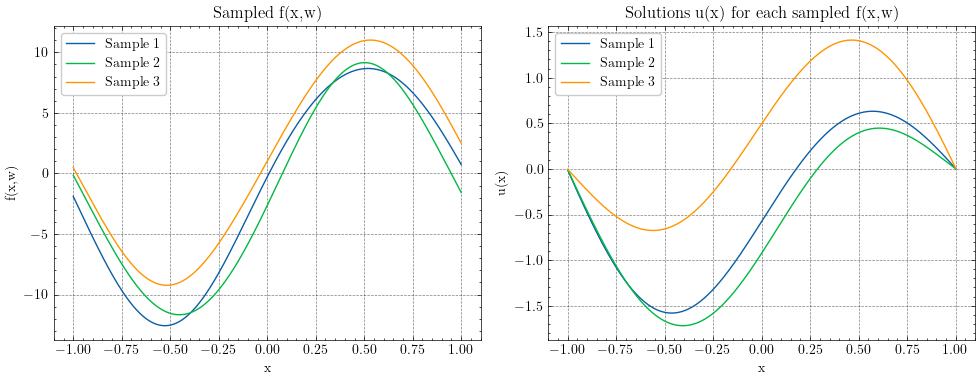

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

#nice plots, optional
import scienceplots
plt.style.use(['science', 'grid'])

# Define parameters
sigma = 1
l = 0.5
n_points = 1000
x = np.linspace(-1, 1, n_points)
dx = x[1] - x[0]

# Define the mean function and the kernel
f0 = lambda x: 10 * np.sin(np.pi * x)

def kernel(x, x_prime, sigma=sigma, l=l):
    return sigma**2 * np.exp(-((x-x_prime)**2) / l**2)

# Sample from the GP
def sample_GP(x, n_samples=1):
    mu = f0(x)
    K = np.array([[kernel(xi, xj) for xj in x] for xi in x])
    return np.random.multivariate_normal(mu, K, n_samples)

# Finite differences using scipy's sparse matrix to solve the Poisson equation
def solve_poisson(f, dx, u_left=0, u_right=0):
    N = len(f)
    diagonals = [-2 * np.ones(N), np.ones(N - 1), np.ones(N - 1)]
    A = diags(diagonals, [0, 1, -1], format="csr")
    A = A / dx**2

    # Set boundary conditions
    f[0] += u_left / dx**2
    f[-1] += u_right / dx**2

    u = spsolve(A, -f)
    return u

# Sample f(x,w) and solve the Poisson equation for each sample
n_samples = 3
f_samples = sample_GP(x, n_samples)
u_solution = np.array([solve_poisson(f_sample, dx) for f_sample in f_samples])

plt.figure(figsize=(10, 4))

# Left subplot for f(x,w)
plt.subplot(1, 2, 1)
for i in range(n_samples):
    plt.plot(x, f_samples[i], label=f"Sample {i+1}")
plt.title("Sampled f(x,w)")
plt.xlabel('x')
plt.ylabel('f(x,w)')
plt.legend()

# Right subplot for u(x)
plt.subplot(1, 2, 2)
for i in range(n_samples):
    plt.plot(x, u_solution[i], label=f"Sample {i+1}")
plt.title("Solutions u(x) for each sampled f(x,w)")
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()

plt.tight_layout()
plt.show()

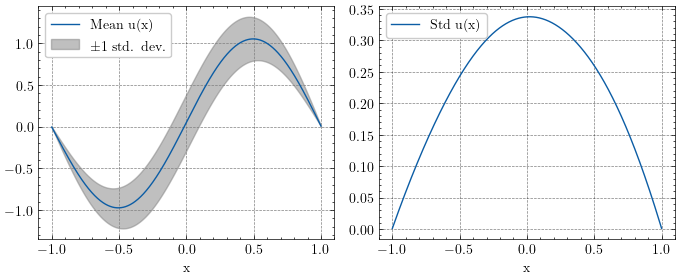

In [ ]:
# Monte Carlo approximation of the mean and standard deviation of the solution

n_points = 1000
x = np.linspace(-1, 1, n_points)
dx = x[1] - x[0]

n_samples = 10000
f_samples = sample_GP(x, n_samples) # Matrix of shape (n_samples, n_points)
u_solution = np.array([solve_poisson(f_sample, dx) for f_sample in f_samples]) # Matrix of shape (n_samples, n_points)

# Calculate the mean and standard deviation along the sample axis
u_mean = u_solution.mean(axis=0)
u_std = u_solution.std(axis=0)

# Plot the mean and standard deviation side by side
fig = plt.figure(figsize=(7, 3))

# Left subplot for mean of u(x)
plt.subplot(1, 2, 1)
plt.plot(x, u_mean, label="Mean u(x)")
plt.fill_between(x, u_mean - u_std, u_mean + u_std, color='gray', alpha=0.5, label="±1 std. dev.")
# plt.title("Mean Solution u(x)")
plt.xlabel('x')
plt.legend()

# Right subplot for standard deviation of u(x)
plt.subplot(1, 2, 2)
plt.plot(x, u_std, label="Std u(x)")
# plt.title("Standard Deviation of Solutions u(x)")
plt.xlabel('x')
plt.legend()

plt.tight_layout()
plt.show()
# fig.savefig('figures/MonteCarlo_mean_std.pdf', bbox_inches='tight')

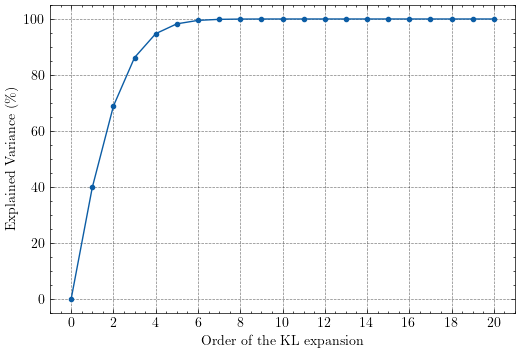

99.0% of variance explained with 6 modes


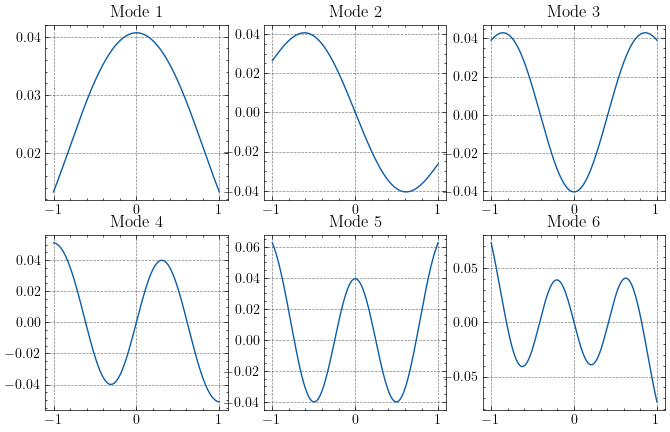

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# Define the GP kernel
def kernel(x, x_prime, sigma=sigma, l=l):
    return sigma**2 * np.exp(-((x-x_prime)**2) / l**2)


def KL_expansion(x, kernel,truncation_order):
    """Compute the KL expansion of the GP prior defined by the kernel function."""
    K = np.array([[kernel(xi, xj) for xj in x] for xi in x])
    eigenvalues, eigenvectors = eigh(K)#,driver='evx')
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    for i in range(truncation_order):
        if eigenvectors[0, i] < 0:
            eigenvectors[:, i] *= -1 # Eigenvectors are defined up to a scalar factor
    return eigenvalues[:truncation_order], eigenvectors[:, :truncation_order]

eigenvalues, eigenvectors = KL_expansion(x, kernel, truncation_order=20)

# Compute the cumulative explained variance
explained_variance = np.cumsum(eigenvalues) / np.sum(eigenvalues) 

# Plot explained variance
fig = plt.figure(figsize=(6, 4))
n_orders = 20
plt.plot(np.arange(0, n_orders + 1), [0] + list(explained_variance[:n_orders] * 100), marker='.')
plt.xlabel('Order of the KL expansion')
plt.ylabel('Explained Variance (\%)')
# plt.title('Explained Variance vs. Order of KL Expansion')
plt.xticks(np.arange(0, n_orders + 1, 2))
plt.show()
# fig.savefig('figures/KL_explained_variance.pdf', format='pdf')
    
# Propose truncation order based on a threshold
threshold = 0.99  # Example threshold for 99% explained variance
truncation_order = np.argmax(explained_variance >= threshold) + 1
print(f"{threshold*100}% of variance explained with {truncation_order} modes")

# Plot the first 6 modes
fig, axs = plt.subplots(2, int(truncation_order/2), figsize=(8, 5))
for i, ax in enumerate(axs.flat):
    ax.plot(x, eigenvectors[:, i], label="$\lambda_{}$ = {:.2f}".format(i+1, eigenvalues[i]))
    ax.set_title(f"Mode {i+1}")
    # ax.legend()
# fig.savefig('figures/KL_modes.pdf', format='pdf')


In [4]:
import time
from tqdm import tqdm
#approximating PCE modes by Monte Carlo
def f_from_xi(xi, x_train, eigenvalues, eigenvectors, f0):
    """Compute the function f(x) from the random variables xi."""
    f_stoch = np.sqrt(eigenvalues) * xi @ eigenvectors.T
    f = f0(x_train) + f_stoch
    return f

t_start = time.time()
seed = 42
n_xi_samples = int(1e3) #number of samples
n_x_points = 1000 #spatial discretization
truncation_order = 6
modes_function = np.zeros((truncation_order, n_x_points))

x_test = np.linspace(-1, 1, n_x_points)
dx = x_test[1] - x_test[0]
eigenvalues, eigenvectors = KL_expansion(x_test, kernel, truncation_order)

np.random.seed(seed) # Set seed for reproducibility
xi_test = np.random.randn(n_xi_samples, truncation_order)

print("f samples :")
f_samples = [f_from_xi(xi, x_test, eigenvalues, eigenvectors, f0) for xi in tqdm(xi_test)]
print("u resolution :")
u_solution = np.array([solve_poisson(f_sample, dx) for f_sample in tqdm(f_samples)]) # Matrix of shape (n_samples, n_points)
u_mean = u_solution.mean(axis=0) # = f0(x_test)/np.pi**2 
u_stoch = u_solution - u_mean
modes_function = np.zeros((truncation_order, len(x_test)))
for mode in range(0,truncation_order):
    xi_mode = xi_test[:,mode]
    modes_function[mode,:] = np.sum(xi_test[:,mode].reshape(-1,1) * u_stoch, axis=0)/n_xi_samples

print(f"Time taken: {time.time() - t_start:.2f} s")

f samples :


100%|██████████| 1000/1000 [00:00<00:00, 20447.75it/s]


u resolution :


100%|██████████| 1000/1000 [00:00<00:00, 1506.62it/s]

Time taken: 3.12 s


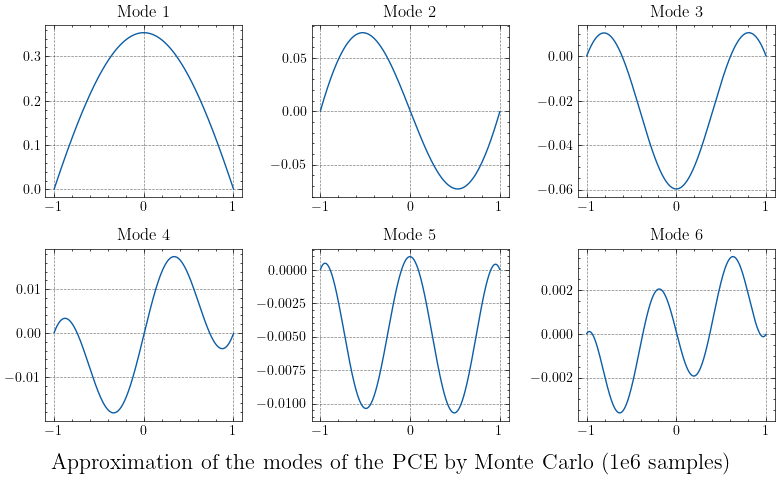

In [5]:
#save the reference solution
save = False
if save:
    np.save(f'MonteCarlo_PCE_modes_1e{np.log10(n_xi_samples)}.npy', modes_function)

# MonteCarlo_PCE_modes = modes_function
MonteCarlo_PCE_modes = np.load('data/MonteCarlo_PCE_modes_1e6.0.npy')

fig, axs = plt.subplots(2, int(len(MonteCarlo_PCE_modes)/2), figsize=(8, 5))
for i, mode in enumerate(MonteCarlo_PCE_modes):
    i_row = i // (len(MonteCarlo_PCE_modes) // 2)
    i_col = i % (len(MonteCarlo_PCE_modes) // 2)
    axs[i_row, i_col].plot(x_test, mode)
    axs[i_row, i_col].set_title(f"Mode {i + 1}")
plt.suptitle(f"Approximation of the modes of the PCE by Monte Carlo (1e6 samples)", y=0, fontsize=16)
plt.tight_layout()
plt.show()
# fig.savefig('figures/MonteCarlo_PCE_modes.pdf', format='pdf')

Monte Carlo converges in $O(N^{-1/2})$ where $N$ is the number of samples.
To be able to approximate modes 6 (order of magnitude $10^{-3}$) we need at least $10^6$ samples

## Implementation of the PINN-PC framework with DeepXDE

In [6]:
import deepxde as dde
# import jax


truncation_order = 6
n_sensors = 13
    
bc_type = "hard" # Choose between "hard" and "soft" boundary conditions
n_x_points = 100
n_xi_samples = 100000
n_xi_batch = 1000
n_sensors = 13
sensors_indices = np.linspace(0, n_x_points - 1, n_sensors, dtype=int)

xi_train = np.random.randn(n_xi_samples, truncation_order) # samples of the random variables
x_train = np.linspace(-1, 1, n_x_points) # spatial discretization used in the KL expansion

eigenvalues, eigenvectors = KL_expansion(x_train, kernel, truncation_order)
f_samples = np.array([f_from_xi(xi, x_train, eigenvalues, eigenvectors, f0) for xi in xi_train])

x_sensor = x_train[sensors_indices] #collocation points to train the pde (where f is known)
f_sensor = f_samples[:,sensors_indices] #value of forcing term at the collocation points

def pde(x, net_output):

    indices = np.random.permutation(xi_train.shape[0])[:n_xi_batch]
    xi_batch = xi_train[indices]
    f_batch = f_sensor[indices]

    u_predicted = net_output[0][:,:1].flatten() + xi_batch @  net_output[0][:,1:].T
    d2u_d2x_mean = dde.grad.hessian(net_output, x)[0].flatten()
    d2u_dx2_coeffs = []
    for i in range(1,net_output[0].shape[1]):  # Loop over the columns (6 in this case)
        d2u_d2x_coeff = dde.grad.hessian(net_output, x, i)[0] 
        d2u_dx2_coeffs.append(d2u_d2x_coeff)

    d2u_dx2_coeffs = dde.backend.stack(d2u_dx2_coeffs, 1).squeeze()
    d2u_dx2 = d2u_d2x_mean + xi_batch @ d2u_dx2_coeffs.T

    pde_residual = d2u_dx2 + f_batch

    losses = [pde_residual]

    if bc_type == "soft":
        bc_left = u_predicted[:,0]
        bc_right = u_predicted[:,-1]
        losses += [bc_left, bc_right]
    return losses

def hard_bc(x, u):
    return u * (1 + x) * (1 - x)

Using backend: jax
Other supported backends: tensorflow.compat.v1, tensorflow, pytorch, paddle.
paddle supports more examples now and is recommended.
Enable just-in-time compilation with XLA.



In [27]:
geom = dde.geometry.Interval(-1, 1)

data = dde.data.PDE(geom, pde, bcs=[], num_domain=0, anchors=x_sensor.reshape(-1,1))

layer_size = [1] + [[4,32]]*3 + [[1,truncation_order]]
activation = "tanh"
initializer = "Glorot uniform"
regularization = ["L2", 1e-5]
net = dde.nn.PFNN(layer_size, activation, initializer, regularization)
if bc_type == "hard":
    net.apply_output_transform(hard_bc)
    
model = dde.Model(data, net)

In [29]:
model.compile("adam", lr=1e-4)
model.train(iterations=30000, display_every=1000)

Compiling model...
'compile' took 0.044754 s

Training model...

0         [7.67e+01, 8.78e-04]    [7.54e+01, 8.78e-04]    []  
1000      [2.86e+01, 8.90e-04]    [2.88e+01, 8.90e-04]    []  
2000      [7.80e+00, 9.17e-04]    [7.83e+00, 9.17e-04]    []  
3000      [4.80e+00, 9.36e-04]    [4.78e+00, 9.36e-04]    []  
4000      [4.11e+00, 9.69e-04]    [4.12e+00, 9.69e-04]    []  
5000      [3.03e+00, 9.92e-04]    [3.05e+00, 9.92e-04]    []  
6000      [2.21e+00, 1.01e-03]    [2.22e+00, 1.01e-03]    []  
7000      [1.60e+00, 1.03e-03]    [1.61e+00, 1.03e-03]    []  
8000      [8.67e-01, 1.05e-03]    [8.71e-01, 1.05e-03]    []  
9000      [2.43e-01, 1.07e-03]    [2.44e-01, 1.07e-03]    []  
10000     [4.84e-02, 1.08e-03]    [4.86e-02, 1.08e-03]    []  
11000     [2.18e-02, 1.08e-03]    [2.18e-02, 1.08e-03]    []  
12000     [1.53e-02, 1.08e-03]    [1.53e-02, 1.08e-03]    []  
13000     [1.04e-02, 1.08e-03]    [1.04e-02, 1.08e-03]    []  
14000     [7.38e-03, 1.07e-03]    [7.38e-03, 1.07e-03

(<deepxde.model.LossHistory at 0x7f9a7f8eca30>,
 <deepxde.model.TrainState at 0x7f9a7f8eee30>)

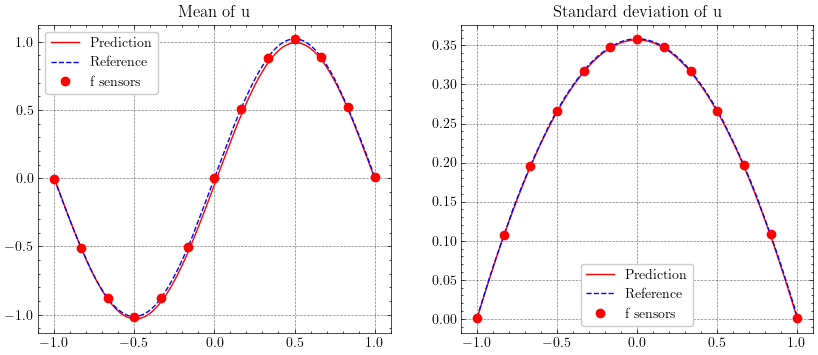

In [25]:
n_x_plot = 100
subsample_ind = [int(i) for i in np.linspace(0,len(u_std)-1,n_x_plot)]
x_sensor = np.linspace(-1, 1, n_sensors)
sensors_indices = np.linspace(0, len(u_std) - 1, n_sensors, dtype=int)
x_plot = np.linspace(-1, 1, n_x_plot).reshape(-1,1)

u_mean_ref = u_mean
u_std_ref = np.sqrt(np.sum(MonteCarlo_PCE_modes**2, axis=0))
# Evaluate the mean_model to get the predicted mean values

predicted_mean = model.predict(x_plot)[:,:1]
coeffs = model.predict(x_plot)[:,1:]

model_std = np.sqrt(np.sum(coeffs**2, axis=1))

# Plot the comparison
fig, axs = plt.subplots(1,2,figsize=(10, 4))
axs[0].plot(x_plot, predicted_mean, 'r-', label="Prediction")
axs[0].plot(x_plot, u_mean_ref[subsample_ind], 'b--', label="Reference")
axs[0].plot(x_sensor, u_mean_ref[sensors_indices], 'ro', label="f sensors")
axs[0].legend()
axs[0].set_title('Mean of u')

axs[1].plot(x_plot, model_std, 'r-', label="Prediction")
axs[1].plot(x_plot, u_std_ref[subsample_ind], 'b--', label="Reference")
axs[1].plot(x_sensor, u_std_ref[sensors_indices], 'ro', label="f sensors")
axs[1].legend()
axs[1].set_title('Standard deviation of u')

fig.savefig('figures/PINN_mean_std.pdf', format='pdf')

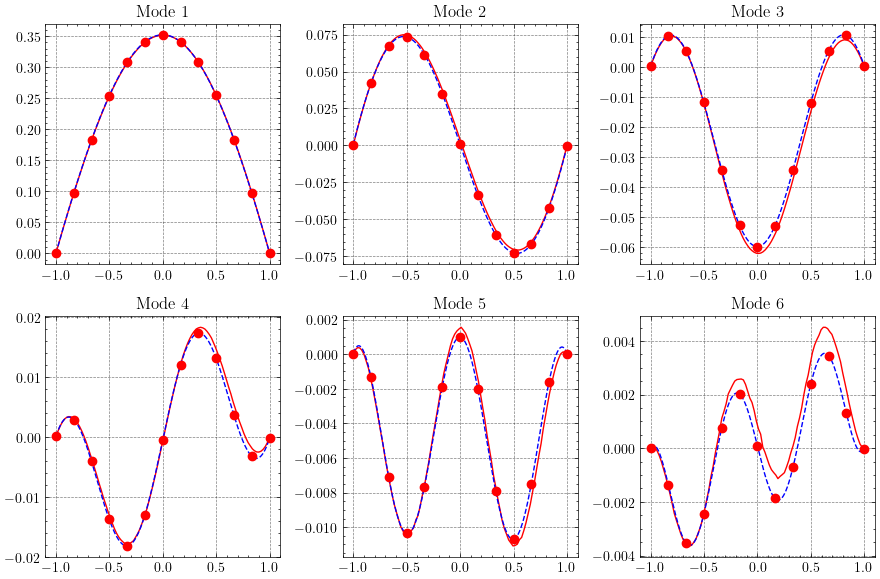

In [26]:
def plot_modes(x_plot, model, modes_to_plot, reference_modes=None):

    coeffs = model.predict(x_plot)[:,1:]
    # Number of modes to plot
    num_modes = len(modes_to_plot)
    
    # Determine the layout for the subplots: 2 columns if more than 3 modes
    n_cols = num_modes if num_modes <= 3 else num_modes // 2 + num_modes % 2
    n_rows = 1 if num_modes <= 3 else 2
    
    # Create subplots for each mode
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
    axs = axs.flatten() if num_modes > 1 else [axs]

    for i, mode in enumerate(modes_to_plot):
        ax = axs[i]
        
        ax.plot(x_plot, coeffs[:, mode-1], 'r-', label="PINN-PCE approx.")

        if reference_modes is not None:
            x_ref = np.linspace(-1, 1, len(reference_modes[mode-1,:]))
            ax.plot(x_ref, reference_modes[mode-1,:], 'b--', label="Reference")
            ax.plot(x_sensor, reference_modes[mode-1, sensors_indices], 'ro', label="f sensors")

        ax.set_title(f"Mode {mode}")
        # ax.legend()

    # Hide any unused subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()
    return fig


# Define the inputs and modes you want to visualize
x_plot = np.linspace(-1, 1, 100).reshape(-1,1)
modes_to_plot = [1,2,3,4,5,6]
reference_modes = np.load('data/MonteCarlo_PCE_modes_1e6.0.npy')

reference_modes[0,:] = reference_modes[0,:] - np.min(reference_modes[0,:])
sensors_indices = np.linspace(0, reference_modes.shape[1] - 1, n_sensors, dtype=int)

fig = plot_modes(x_plot,model, modes_to_plot, reference_modes=reference_modes)
fig.savefig('figures/PINN_PCE_modes.pdf', format='pdf')